# Analysis: Learning More About Matched Individuals

In [199]:
import pandas as pd
import matplotlib.pyplot as plt

In [177]:
loan_office_certificates = pd.read_csv("loan_office_certificates.csv")
post_1790 = pd.read_csv("post_1790.csv")

In [178]:
loan_office_certificates["raw_name_state"].head()

0     JOSHUA WENTWORTH||NH
1    CHARLES TREADWELL||NH
2     STEPHEN CLEVERLY||NH
3       DAVID GRIFFITH||NH
4       JOHN MANSFIELD||NH
Name: raw_name_state, dtype: object

## Percent of Total Debt Held By Matches

In [179]:
# find total value of all debt certificates
total = loan_office_certificates["Face Value"].sum()
print(total) 

56419829


In [180]:
# find total owned by matched names
total_matched = loan_office_certificates[loan_office_certificates["matched_status"]]["Face Value"].sum()
print(total_matched)

11358669


In [181]:
# calculate percentage 
print((total_matched / total) * 100)

20.132405931255125


In [182]:
# what percentage of debtholders did the matches make up
total_unique_names = loan_office_certificates["raw_name_state"].nunique()
total_unique_matched_names = loan_office_certificates[loan_office_certificates["matched_status"]]["raw_name_state"].nunique()
print("total unique names: " + str(total_unique_names))
print("total unique matched names: " + str(total_unique_matched_names))

print((total_unique_matched_names / total_unique_names) * 100)

total unique names: 17173
total unique matched names: 831
4.8389914400512435


## Average Amoung Held By Matches VS Non-Matches

In [183]:
# filter only for matched rows
matched_df = loan_office_certificates[loan_office_certificates["matched_status"]]
# group rows by individuals, summing their certificates
grouped_matched = matched_df.groupby("raw_name_state")["Face Value"].sum()

In [184]:
# calculate average
average_matched = grouped_matched.mean()
print(average_matched)

13668.675090252707


In [185]:
# filter only for non-matched rows
nonmatched_df = loan_office_certificates[~loan_office_certificates["matched_status"]]
print(str(nonmatched_df.shape[0]) + " total rows")

grouped_nonmatched = nonmatched_df.groupby("raw_name_state")["Face Value"].sum()

66667 total rows


In [186]:
# calculate average
average_nonmatched = grouped_nonmatched.mean()
print(average_nonmatched)

2757.3834292008323


In [187]:
average_matched - average_nonmatched

np.float64(10911.291661051875)

## Comparing Holdings Before and After 1790

In [188]:
# create reconcile id column that corresponds to "A[column + 2]:Z[column + 2]"
post_1790["recon_id"] = post_1790["Column"].apply(lambda x: f"A{x + 2}:Z{x + 2}")
post_1790["recon_id"].head()

0    A2:Z2
1    A3:Z3
2    A4:Z4
3    A5:Z5
4    A6:Z6
Name: recon_id, dtype: object

In [ ]:
# get a list of reconcile ids from matched names from pre-1790 dataset
matched_recon_ids = loan_office_certificates.loc[loan_office_certificates["matched_status"], "recon_id"].dropna().unique()
print("example: " + matched_recon_ids[0]) # expect: A3339:Z3339

example: A3339:Z3339


In [190]:
# create a matched_status column in post-1790 dataset
post_1790["matched_status"] = post_1790["recon_id"].isin(matched_recon_ids) 
count = len(post_1790[post_1790["matched_status"] == True])
print(count)

843


In [191]:
# see how many names were missed
matched_names_set = set(loan_office_certificates.loc[loan_office_certificates["matched_status"], "recon_id"].dropna().unique())
post_names_set = set(post_1790["recon_id"].unique())

# get a set of all missed names
missing = matched_names_set - post_names_set
print(f"{len(missing)} names from pre-1790 matched list not found in post-1790:")
print(sorted(missing))

0 names from pre-1790 matched list not found in post-1790:
[]


In [192]:
# get total owned by matches in pre-1790 dataset
total_matched_pre = loan_office_certificates.loc[loan_office_certificates["matched_status"], "Face Value"].sum()
# get total owned by matches in post-1790 dataset
total_matched_post = post_1790.loc[post_1790["matched_status"], "final_total_adj"].sum()
print(f"total owned by matches (pre-1790): ${total_matched_pre:.2f}")
print(f"total owned by matches (post-1790): ${total_matched_post:.2f}")

total owned by matches (pre-1790): $11358669.00
total owned by matches (post-1790): $2761541.75


In [193]:
# save post-1790 file with matched_status for future use
post_1790.to_csv("post_1790_with_matched_status.csv", index=False)

In [ ]:
# calculate percent change per person

# group individuals by their reconcile id with their pre-1790 and post-1790 sums
pre_totals = loan_office_certificates.groupby("recon_id")["Face Value"].sum().rename("pre_value")
post_totals = post_1790.groupby("recon_id")["final_total_adj"].sum().rename("post_value")

In [195]:
# combine reconcile id, pre-1790 sum, post-1790 sum into a single data frame
combined = pd.concat([pre_totals, post_totals], axis=1)
combined.head()

,pre_value,post_value
recon_id,,
A100:Z100,2000.0,325.82
A1016:Z1016,1400.0,922.92
A1023:Z1023,53600.0,0.00
A1024:Z1024,31400.0,9397.77
A1026:Z1026,4500.0,411.50


In [196]:
# create a new percent change column
combined["percent_change"] = (combined["post_value"] - combined["pre_value"]) / combined["pre_value"] * 100

In [197]:
# inspect first few results
combined.head()

,pre_value,post_value,percent_change
recon_id,,,
A100:Z100,2000.0,325.82,-83.709000
A1016:Z1016,1400.0,922.92,-34.077143
A1023:Z1023,53600.0,0.00,-100.000000
A1024:Z1024,31400.0,9397.77,-70.070796
A1026:Z1026,4500.0,411.50,-90.855556


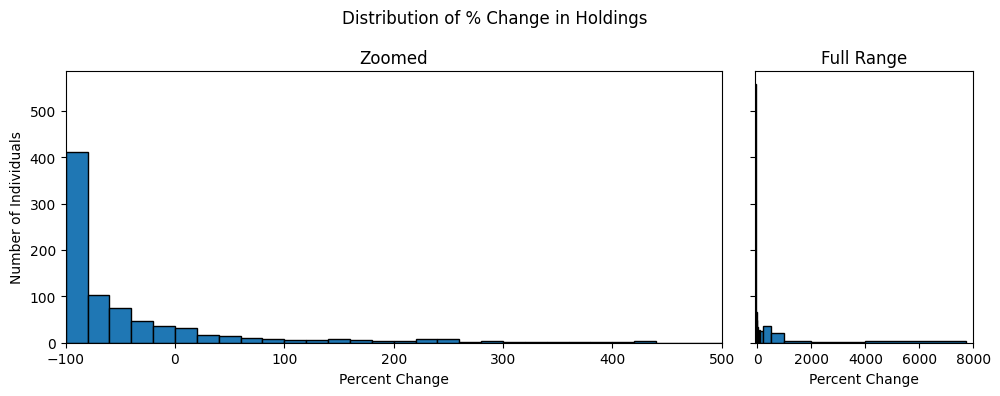

In [211]:
min_percent = combined["percent_change"].min()
max_percent = combined["percent_change"].max()

# create two panels: one full and one zoomed-in
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10,4),
                               gridspec_kw={"width_ratios":[3,1]})

# Main zoomed view
bins_zoom = list(range(int(min_percent), 501, 20))
ax1.hist(combined["percent_change"], bins=bins_zoom, edgecolor='black')
ax1.set_xlim(int(min_percent), 500)
ax1.set_title("Zoomed")
ax1.set_xlabel("Percent Change")

# Full-range view
bins_full = [min_percent,-50, -25, 0,25,50,100,200,500,1000,2000,4000,max_percent]
ax2.hist(combined["percent_change"], bins=bins_full, edgecolor='black')
ax2.set_xlim(-100,8000)
ax2.set_title("Full Range")
ax2.set_xlabel("Percent Change")

fig.suptitle("Distribution of % Change in Holdings")
ax1.set_ylabel("Number of Individuals")
plt.tight_layout()
plt.show()

In [ ]:
# see outliers
outliers = combined.sort_values(by="percent_change", ascending=False)
print(outliers.head(10))

             pre_value  post_value  percent_change
recon_id                                          
A2176:Z2176      200.0    15628.78     7714.390000
A2957:Z2957      600.0    38453.05     6308.841667
A1192:Z1192      500.0    25583.82     5016.764000
A1319:Z1319      200.0     9094.72     4447.360000
A2297:Z2297      900.0    24607.93     2634.214444
A627:Z627        300.0     4292.81     1330.936667
A2420:Z2420      400.0     4891.24     1122.810000
A940:Z940        200.0     2284.17     1042.085000
A1561:Z1561     3500.0    37942.33      984.066571
A1871:Z1871      400.0     4219.00      954.750000


In [215]:
# how many doubled their holdings
more_than_doubled = outliers[outliers["percent_change"] > 200]
count_large = len(more_than_doubled)
print(count_large)

66


In [213]:
# find average percent change
combined["percent_change"].median()

np.float64(-77.86115384615384)